# Kepler Orbit

In [1]:
import numpy as np
from scipy.optimize import newton
import matplotlib.pyplot as plt

In [2]:
def kepler_orbit(a, e, omega_deg, Omega_deg, inc_deg, M_BH, times):
   # Convert angles to radians
    omega = np.radians(omega_deg)
    Omega = np.radians(Omega_deg)
    inc = np.radians(inc_deg)
    
    # Mean motion (rad/yr)
    n = np.sqrt(M_BH / a**3)
    
    # Initialize output arrays - sky coordinates
    x_sky, y_sky = np.zeros_like(times), np.zeros_like(times)
    
    for i, t in enumerate(times):
        # Mean anomaly
        M = n * t
        
        # Solve Kepler's equation for eccentric anomaly E
        def f(E):
            return E - e * np.sin(E) - M
        E = newton(f, x0=M) 
        
        # True anomaly
        varphi = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E/2), np.sqrt(1 - e) * np.cos(E/2))
        
        # Radial distance
        r = a * (1 - e * np.cos(E))
        
        # Position in orbital plane
        x_orb = r * np.cos(varphi)
        y_orb = r * np.sin(varphi)
        z_orb = 0
        
        # Rotate to sky coordinates
        # We define rotation matrices
        def R_z(theta):
            return np.array([
                [np.cos(theta), -np.sin(theta), 0],
                [np.sin(theta), np.cos(theta), 0],
                [0, 0, 1]
            ])

        def R_x(theta):
            return np.array([
                [1, 0, 0],
                [0, np.cos(theta), -np.sin(theta)],
                [0, np.sin(theta), np.cos(theta)]
            ])

        # Combined rotation
        R = R_z(-Omega) @ R_x(-inc) @ R_z(-omega)

        r_sky = R @ np.array([x_orb, y_orb, z_orb])
        x_sky[i], y_sky[i], _ = r_sky

    return x_sky, y_sky

## Using the Model

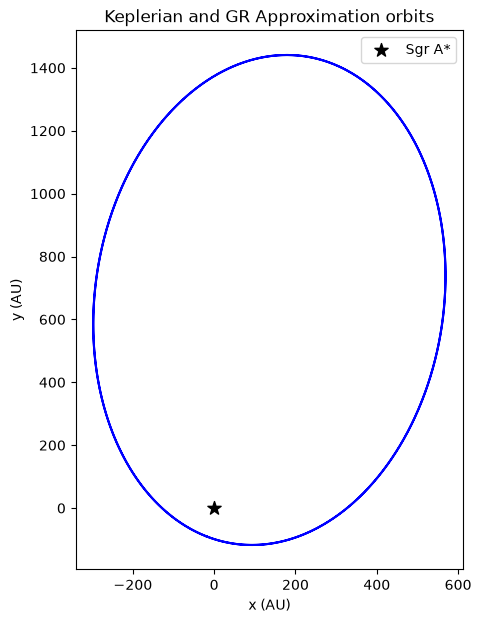

In [3]:
# Parameters
M_BH = 5e6  # Solar masses
a = 1000      # AU
e = 0.88
inc = 135     # deg
omega = 65    # deg
Omega = 225   # deg
times = np.linspace(0, 4*np.pi*np.sqrt(a**3/M_BH), 10000)

x_kepler, y_kepler = kepler_orbit(a, e, omega, Omega, inc, M_BH, times)
plt.figure(figsize=(5, 7))

plt.plot(y_kepler, x_kepler,'b-')
plt.scatter([0], [0], c='k', marker='*', s=100, label="Sgr A*")
plt.legend()
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Keplerian and GR Approximation orbits")
plt.savefig("kepler-model.pdf")